In [3]:
from google.colab import drive
drive.mount('/content/drive')

!pip -q install xgboost shap pandas numpy scipy scikit-learn matplotlib seaborn tqdm

import os, json, gc
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# EDIT THIS
JSONL_PATH = '/content/drive/MyDrive/Colab Notebooks/out_features.jsonl'
OUTPUT_DIR = '/content/drive/MyDrive/Colab Notebooks/feature_audit_v2'

Path(OUTPUT_DIR, 'tables').mkdir(parents=True, exist_ok=True)
Path(OUTPUT_DIR, 'plots').mkdir(parents=True, exist_ok=True)

print('JSONL exists:', os.path.exists(JSONL_PATH),
      f'size: {os.path.getsize(JSONL_PATH)/1e6:.1f} MB' if os.path.exists(JSONL_PATH) else 'N/A')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
JSONL exists: True size: 1133.4 MB


In [4]:
records    = []
fire_lists = []

with open(JSONL_PATH, 'r', encoding='utf-8') as f:
    for line in tqdm(f, desc='loading'):
        line = line.strip()
        if not line: continue
        try:
            r = json.loads(line)
        except Exception:
            continue
        label = (r.get('label') or '').lower()
        if label not in ('phishing','benign'): continue

        meas  = r.get('measurements') or {}
        feats = r.get('features') or []

        seen_ids = sorted({fo.get('id') for fo in feats if fo.get('id')})

        rec = {
            'id': r.get('id'),
            'label': label,
            'source': r.get('source'),
        }
        for k, v in meas.items():
            if isinstance(v, bool):
                rec[f'm_{k}'] = int(v)
            elif isinstance(v, (int, float)):
                rec[f'm_{k}'] = v
            elif isinstance(v, list):
                rec[f'm_{k}'] = len(v)
            elif isinstance(v, dict):
                rec[f'm_{k}'] = len(v)
        records.append(rec)
        fire_lists.append(seen_ids)

records_df = pd.DataFrame(records)
y          = (records_df['label']=='phishing').astype(int).values
src        = (records_df['source']=='phishing_db.website_content').astype(int).values

# Binary fired-features matrix
all_fids = sorted({fid for lst in fire_lists for fid in lst})
fid_to_idx = {fid: i for i, fid in enumerate(all_fids)}
rows_, cols_ = [], []
for ridx, lst in enumerate(fire_lists):
    for fid in lst:
        rows_.append(ridx); cols_.append(fid_to_idx[fid])
X_fire = sp.csr_matrix((np.ones(len(rows_), dtype=np.int8), (rows_, cols_)),
                       shape=(len(fire_lists), len(all_fids)))

# Numeric measurements matrix
from sklearn.impute import SimpleImputer
num_cols = [c for c in records_df.columns if c.startswith('m_')]
X_num = records_df[num_cols].astype(float)
X_num = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(X_num),
                     columns=num_cols, index=X_num.index)

# Combined matrix
X_full = sp.hstack([X_fire, sp.csr_matrix(X_num.values)]).tocsr()
all_columns = all_fids + num_cols

print(f'\nRecords: {len(records_df):,}')
print(f'Fired features: {len(all_fids)}')
print(f'Numeric measurements: {len(num_cols)}')
print(f'Combined matrix: {X_full.shape}')
print(f'Class balance: {dict(zip(*np.unique(y, return_counts=True)))}')

loading: 0it [00:00, ?it/s]


Records: 80,000
Fired features: 36
Numeric measurements: 21
Combined matrix: (80000, 57)
Class balance: {np.int64(0): np.int64(40000), np.int64(1): np.int64(40000)}


In [5]:
from sklearn.model_selection import train_test_split

idx = np.arange(X_full.shape[0])
idx_tr, idx_tmp = train_test_split(idx, test_size=0.30, stratify=y, random_state=42)
idx_va, idx_te  = train_test_split(idx_tmp, test_size=0.50, stratify=y[idx_tmp], random_state=42)

X_tr, X_va, X_te = X_full[idx_tr], X_full[idx_va], X_full[idx_te]
y_tr, y_va, y_te = y[idx_tr], y[idx_va], y[idx_te]
src_tr, src_va, src_te = src[idx_tr], src[idx_va], src[idx_te]

print(f'train: {X_tr.shape[0]:,}   val: {X_va.shape[0]:,}   test: {X_te.shape[0]:,}')

train: 56,000   val: 12,000   test: 12,000


In [6]:
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, accuracy_score

def train_xgb(X_tr, y_tr, X_va, y_va, n_est=400, max_depth=6, lr=0.1):
    clf = XGBClassifier(
        n_estimators=n_est, max_depth=max_depth, learning_rate=lr,
        tree_method='hist', n_jobs=-1, random_state=0, eval_metric='logloss',
        verbosity=0)
    clf.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    return clf

print('Training baseline on full feature set...')
clf_full = train_xgb(X_tr, y_tr, X_va, y_va)
pred_te  = clf_full.predict(X_te)
F1_BASELINE  = f1_score(y_te, pred_te)
ACC_BASELINE = accuracy_score(y_te, pred_te)

print(f'\nBaseline:')
print(f'  F1:       {F1_BASELINE:.4f}')
print(f'  accuracy: {ACC_BASELINE:.4f}')
print(f'  total features: {X_full.shape[1]}')

Training baseline on full feature set...

Baseline:
  F1:       0.9722
  accuracy: 0.9723
  total features: 57


In [7]:
print(f'Running LOFO ablation on {len(all_columns)} features...')
print('Each iteration trains a fresh XGBoost with ONE feature removed.\n')

lofo_results = []
for i, fname in enumerate(tqdm(all_columns, desc='LOFO')):
    # Drop column i from train/val/test
    keep = [j for j in range(X_full.shape[1]) if j != i]
    Xtr_k = X_tr[:, keep]; Xva_k = X_va[:, keep]; Xte_k = X_te[:, keep]
    clf_k = train_xgb(Xtr_k, y_tr, Xva_k, y_va)
    pred  = clf_k.predict(Xte_k)
    f1_dropped = f1_score(y_te, pred)
    lofo_results.append({
        'feature': fname,
        'f1_without_this_feature': f1_dropped,
        'f1_drop_vs_baseline':     F1_BASELINE - f1_dropped,
    })

lofo_df = pd.DataFrame(lofo_results).sort_values('f1_drop_vs_baseline', ascending=False)
lofo_df.to_csv(Path(OUTPUT_DIR, 'tables', 'lofo_results.csv'), index=False)

print(f'\nBaseline F1: {F1_BASELINE:.4f}')
print('\nTop 15 features by LOFO impact (largest F1 drop when removed):')
print(lofo_df.head(15).to_string(index=False))
print('\nBottom 10 features by LOFO impact (no F1 drop when removed):')
print(lofo_df.tail(10).to_string(index=False))

Running LOFO ablation on 57 features...
Each iteration trains a fresh XGBoost with ONE feature removed.



LOFO:   0%|          | 0/57 [00:00<?, ?it/s]


Baseline F1: 0.9722

Top 15 features by LOFO impact (largest F1 drop when removed):
                                        feature  f1_without_this_feature  f1_drop_vs_baseline
                               m_redirect_count                 0.969337             0.002894
                           iframe.hidden_iframe                 0.970016             0.002216
                       m_image_src_sample_count                 0.970178             0.002054
                                   m_url_length                 0.970224             0.002007
                            m_null_anchor_count                 0.970264             0.001968
                      m_script_src_sample_count                 0.970421             0.001810
                          m_visible_text_length                 0.970421             0.001810
                    form.action_same_org_domain                 0.970502             0.001729
                        m_external_anchor_count                 0.970

In [8]:
print(f'Running per-feature cheating detector on {len(all_columns)} features...')
print('Each iteration trains XGBoost with ONLY one feature, predicting SOURCE.\n')

cheat_results = []
for i, fname in enumerate(tqdm(all_columns, desc='cheating')):
    Xtr_1 = X_tr[:, [i]]; Xva_1 = X_va[:, [i]]; Xte_1 = X_te[:, [i]]
    clf_1 = train_xgb(Xtr_1, src_tr, Xva_1, src_va, n_est=200, max_depth=4)
    pred_src = clf_1.predict(Xte_1)
    src_acc  = accuracy_score(src_te, pred_src)
    cheat_results.append({
        'feature': fname,
        'source_prediction_accuracy_alone': src_acc,
    })

cheat_df = pd.DataFrame(cheat_results).sort_values(
    'source_prediction_accuracy_alone', ascending=False)
cheat_df.to_csv(Path(OUTPUT_DIR, 'tables', 'cheating_per_feature.csv'), index=False)

print('\nTop 15 features that alone predict source (potential leakers):')
print(cheat_df.head(15).to_string(index=False))
print('\nBottom 10 features (cannot predict source — likely real phishing signals):')
print(cheat_df.tail(10).to_string(index=False))

Running per-feature cheating detector on 57 features...
Each iteration trains XGBoost with ONLY one feature, predicting SOURCE.



cheating:   0%|          | 0/57 [00:00<?, ?it/s]


Top 15 features that alone predict source (potential leakers):
                             feature  source_prediction_accuracy_alone
      m_internal_nav_candidate_count                          0.872250
navigation.functional_internal_links                          0.846167
                      m_anchor_count                          0.830167
           m_script_src_sample_count                          0.774833
             m_external_anchor_ratio                          0.769083
               m_visible_text_length                          0.762417
             m_external_anchor_count                          0.727917
            m_image_src_sample_count                          0.724833
            m_contact_anchor_domains                          0.710417
                    m_redirect_count                          0.672750
                     m_favicon_count                          0.665750
      m_stylesheet_href_sample_count                          0.656417
             

Running TreeSHAP on baseline model...

Top 15 features by SHAP importance:
                          feature  mean_abs_shap
               url.http_not_https       2.064513
      brand.title_domain_mismatch       1.436286
                 m_redirect_count       1.332031
            redirect.cross_domain       1.092666
          m_external_anchor_ratio       0.842581
              m_null_anchor_count       0.815584
                   m_anchor_count       0.806208
   m_internal_nav_candidate_count       0.729000
             iframe.hidden_iframe       0.683798
    brand.favicon_domain_mismatch       0.659971
        m_script_src_sample_count       0.646303
content.copyright_domain_mismatch       0.623585
               url.deep_subdomain       0.492890
         m_contact_anchor_domains       0.439892
            m_visible_text_length       0.439514


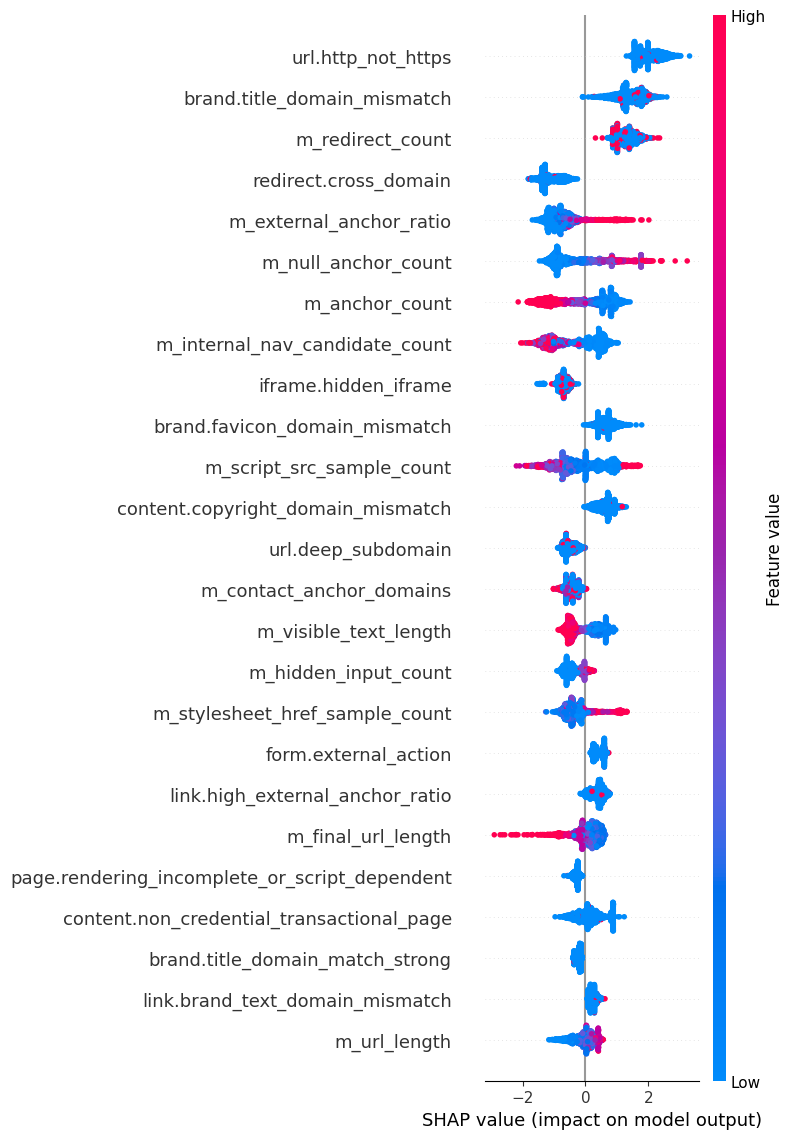

In [9]:
import shap

print('Running TreeSHAP on baseline model...')

# SHAP on a sample of the test set (full SHAP can be slow on huge sparse matrices)
SHAP_SAMPLE = 2000
sample_idx = np.random.RandomState(0).choice(X_te.shape[0],
                                              size=min(SHAP_SAMPLE, X_te.shape[0]),
                                              replace=False)
X_te_dense = X_te[sample_idx].toarray()

explainer = shap.TreeExplainer(clf_full)
shap_vals = explainer.shap_values(X_te_dense)

# For binary classification, shap_values may be a single array (positive class)
# or a list of two (one per class). Handle both.
if isinstance(shap_vals, list) and len(shap_vals) == 2:
    shap_arr = shap_vals[1]   # positive class (phishing)
else:
    shap_arr = shap_vals

mean_abs_shap = np.abs(shap_arr).mean(axis=0)

shap_df = pd.DataFrame({
    'feature': all_columns,
    'mean_abs_shap': mean_abs_shap,
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

shap_df.to_csv(Path(OUTPUT_DIR, 'tables', 'shap_importance.csv'), index=False)

print(f'\nTop 15 features by SHAP importance:')
print(shap_df.head(15).to_string(index=False))

# Beeswarm plot
fig = plt.figure(figsize=(10, 9))
shap.summary_plot(shap_arr, X_te_dense, feature_names=all_columns,
                  max_display=25, show=False)
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR, 'plots', 'shap_summary.png'), dpi=140, bbox_inches='tight')
plt.show()

In [10]:
combined = (lofo_df
    .merge(cheat_df,  on='feature', how='outer')
    .merge(shap_df,   on='feature', how='outer')
)

# Normalize each metric to a 0-1 scale so they're comparable
def normalize(s):
    s = s.fillna(s.median())
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng > 0 else s * 0.0

combined['lofo_score']  = normalize(combined['f1_drop_vs_baseline'])
combined['cheat_score'] = normalize(combined['source_prediction_accuracy_alone'])
combined['shap_score']  = normalize(combined['mean_abs_shap'])

# Recommendation logic
def recommend(r):
    high_impact   = r['lofo_score']  > 0.30 or r['shap_score'] > 0.30
    high_cheat    = r['cheat_score'] > 0.60   # source-pred accuracy notably above 50% chance
    no_impact     = r['lofo_score']  < 0.05 and r['shap_score'] < 0.05

    if high_impact and high_cheat:
        return 'DROP — high impact but high source leak (artifact)'
    if high_impact and not high_cheat:
        return 'KEEP — high impact, no source leak (real signal)'
    if no_impact:
        return 'DROP — no measurable impact (dead weight)'
    if high_cheat:
        return 'DROP — predicts source on its own'
    return 'KEEP — moderate signal, no leak'

combined['recommendation'] = combined.apply(recommend, axis=1)

# Sort: drop reasons first by impact, then keeps by impact
combined = combined.sort_values('lofo_score', ascending=False).reset_index(drop=True)
combined.to_csv(Path(OUTPUT_DIR, 'tables', 'final_decision_table.csv'), index=False)

print('Recommendation summary:')
print(combined['recommendation'].value_counts())
print()

# Show full table
pd.set_option('display.max_rows', 100)
print(combined[['feature','f1_drop_vs_baseline','source_prediction_accuracy_alone',
                'mean_abs_shap','recommendation']].round(4).to_string(index=False))

Recommendation summary:
recommendation
KEEP — moderate signal, no leak                       26
KEEP — high impact, no source leak (real signal)      23
DROP — high impact but high source leak (artifact)     7
DROP — predicts source on its own                      1
Name: count, dtype: int64

                                        feature  f1_drop_vs_baseline  source_prediction_accuracy_alone  mean_abs_shap                                     recommendation
                               m_redirect_count               0.0029                            0.6728         1.3320   KEEP — high impact, no source leak (real signal)
                           iframe.hidden_iframe               0.0022                            0.6553         0.6838   KEEP — high impact, no source leak (real signal)
                       m_image_src_sample_count               0.0021                            0.7248         0.1793 DROP — high impact but high source leak (artifact)
                              

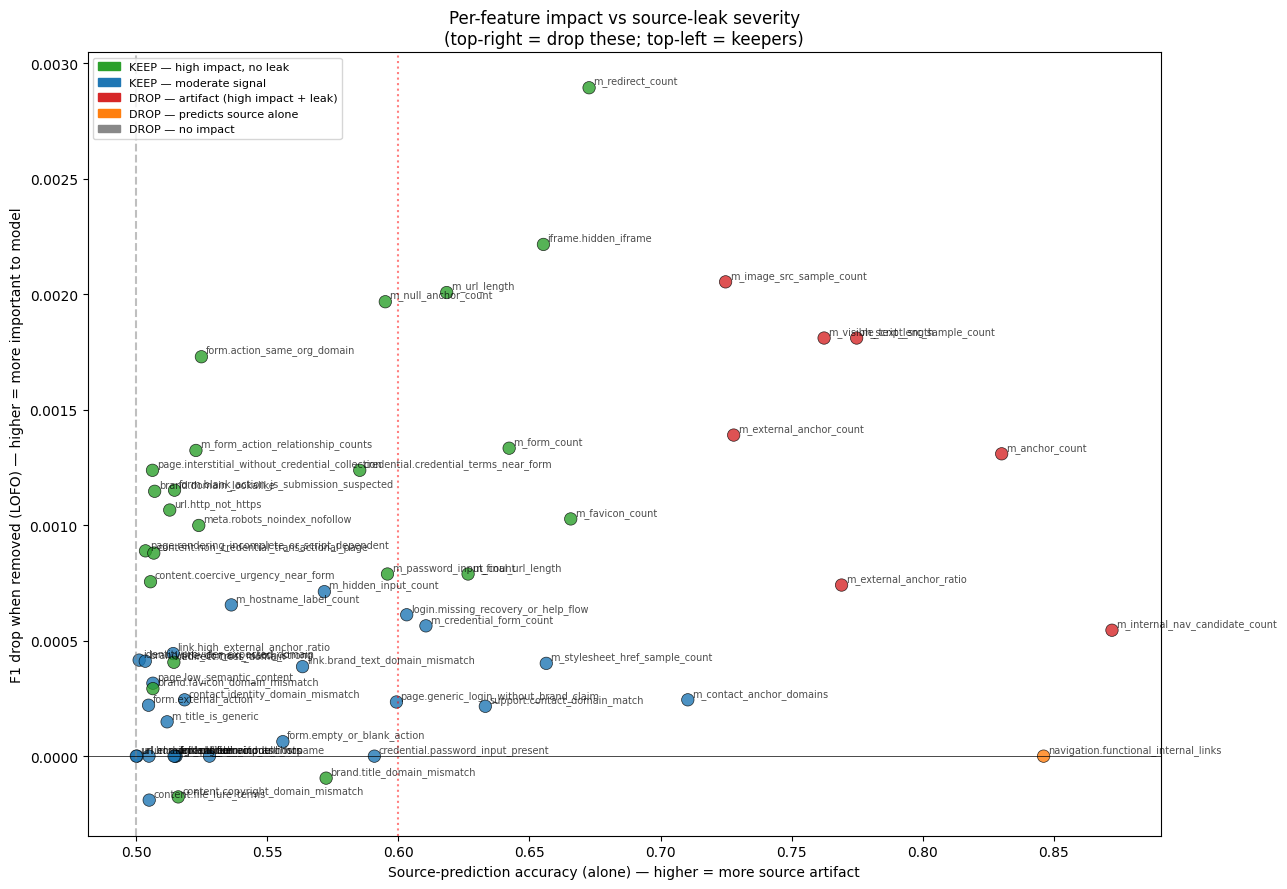

In [11]:
fig, ax = plt.subplots(figsize=(13, 9))

x = combined['source_prediction_accuracy_alone']
y = combined['f1_drop_vs_baseline']

# Color by recommendation
colors = combined['recommendation'].map({
    'KEEP — high impact, no source leak (real signal)': '#2ca02c',
    'KEEP — moderate signal, no leak':                  '#1f77b4',
    'DROP — high impact but high source leak (artifact)': '#d62728',
    'DROP — predicts source on its own':                '#ff7f0e',
    'DROP — no measurable impact (dead weight)':        '#888888',
}).fillna('#cccccc')

ax.scatter(x, y, c=colors, s=80, edgecolor='k', linewidth=0.5, alpha=0.8)

# Annotate every feature
for _, r in combined.iterrows():
    ax.annotate(r['feature'], (r['source_prediction_accuracy_alone'],
                               r['f1_drop_vs_baseline']),
                fontsize=7, alpha=0.7, xytext=(3,3), textcoords='offset points')

# Reference lines
ax.axvline(0.5,  color='gray', linestyle='--', alpha=0.5, label='source = chance (0.5)')
ax.axvline(0.6,  color='red',  linestyle=':',  alpha=0.5, label='source-leak threshold (0.6)')
ax.axhline(0.0,  color='black', linewidth=0.5)

ax.set_xlabel('Source-prediction accuracy (alone) — higher = more source artifact')
ax.set_ylabel('F1 drop when removed (LOFO) — higher = more important to model')
ax.set_title('Per-feature impact vs source-leak severity\n(top-right = drop these; top-left = keepers)')

# Legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(color='#2ca02c', label='KEEP — high impact, no leak'),
    Patch(color='#1f77b4', label='KEEP — moderate signal'),
    Patch(color='#d62728', label='DROP — artifact (high impact + leak)'),
    Patch(color='#ff7f0e', label='DROP — predicts source alone'),
    Patch(color='#888888', label='DROP — no impact'),
]
ax.legend(handles=legend_handles, loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR, 'plots', 'impact_vs_leak_scatter.png'), dpi=140, bbox_inches='tight')
plt.show()

In [12]:
final_keep = combined[combined['recommendation'].str.startswith('KEEP')]
final_drop = combined[combined['recommendation'].str.startswith('DROP')]

print('='*70)
print('FINAL FEATURE DECISIONS — based on three independent criteria')
print('='*70)
print(f'\nBaseline F1 (full features): {F1_BASELINE:.4f}')
print(f'\nTotal features analyzed: {len(combined)}')
print(f'  KEEP: {len(final_keep)}')
print(f'  DROP: {len(final_drop)}')

print(f'\n{"-"*70}\nFEATURES TO KEEP (sorted by importance):')
print(final_keep[['feature','f1_drop_vs_baseline',
                  'source_prediction_accuracy_alone','mean_abs_shap']].round(4).to_string(index=False))

print(f'\n{"-"*70}\nFEATURES TO DROP (sorted by impact):')
print(final_drop[['feature','f1_drop_vs_baseline',
                  'source_prediction_accuracy_alone','mean_abs_shap',
                  'recommendation']].round(4).to_string(index=False))

# Save the final keep/drop lists as plain text for easy use later
keep_list = final_keep['feature'].tolist()
drop_list = final_drop['feature'].tolist()

Path(OUTPUT_DIR, 'tables', 'features_to_keep.txt').write_text('\n'.join(keep_list))
Path(OUTPUT_DIR, 'tables', 'features_to_drop.txt').write_text('\n'.join(drop_list))
print(f'\nSaved keep/drop lists to {OUTPUT_DIR}/tables/')

FINAL FEATURE DECISIONS — based on three independent criteria

Baseline F1 (full features): 0.9722

Total features analyzed: 57
  KEEP: 49
  DROP: 8

----------------------------------------------------------------------
FEATURES TO KEEP (sorted by importance):
                                        feature  f1_drop_vs_baseline  source_prediction_accuracy_alone  mean_abs_shap
                               m_redirect_count               0.0029                            0.6728         1.3320
                           iframe.hidden_iframe               0.0022                            0.6553         0.6838
                                   m_url_length               0.0020                            0.6184         0.2416
                            m_null_anchor_count               0.0020                            0.5950         0.8156
                    form.action_same_org_domain               0.0017                            0.5248         0.1833
                              

In [13]:
from google.colab import drive, runtime
import time
drive.flush_and_unmount()
print('Drive flushed. Disconnecting in 10s...')
time.sleep(10)
runtime.unassign()

Drive flushed. Disconnecting in 10s...
